In [273]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn import datasets
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

X_train = pd.read_parquet("../data/processed/X_train.parquet")
X_test = pd.read_parquet("../data/processed/X_test.parquet")
X_val = pd.read_parquet("../data/processed/X_val.parquet")

y_train = pd.read_parquet("../data/processed/y_train.parquet")["price"]
y_val = pd.read_parquet("../data/processed/y_val.parquet")["price"]
y_test = pd.read_parquet("../data/processed/y_test.parquet")["price"]

In [274]:
X_train.head(10)

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,salvage,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported
1201912,Orlando,V6,True,Gasoline,False,283.0,False,Dodge,144084.0,Grand Caravan,...,False,A,SE FWD,FWD,2013,0,0,False,False,True
770704,Princeton,V6,False,Gasoline,False,270.0,False,Toyota,65165.0,Highlander,...,False,A,XLE V6 AWD,AWD,2015,0,0,False,False,True
1416224,Melbourne,V8 Flex Fuel Vehicle,False,Flex Fuel Vehicle,False,355.0,False,Chevrolet,58107.0,Tahoe,...,False,A,LT RWD,4X2,2017,0,0,False,False,True
250456,Catskill,V6,Not Reported,Gasoline,Not Reported,450.0,True,Ford,5.0,F-150,...,Not Reported,A,Limited SuperCrew 4WD,4WD,2020,0,0,False,False,False
2545573,Riverside,I4,False,Gasoline,False,150.0,False,Volkswagen,33709.0,Jetta,...,False,A,1.4T S FWD,FWD,2017,0,0,False,False,True
2149151,Dallas,V10,False,Gasoline,True,500.0,False,Dodge,19789.0,Viper,...,True,M,SRT10 Roadster RWD,RWD,2005,0,0,False,False,True
1904730,Tahlequah,V8,False,Gasoline,False,370.0,False,Dodge,21422.0,Charger,...,False,A,Daytona RWD,RWD,2017,0,0,False,False,True
660149,El Paso,V8,Not Reported,Gasoline,Not Reported,420.0,True,GMC,7.0,Sierra 1500,...,Not Reported,A,AT4 Crew Cab 4WD,4WD,2020,0,0,False,False,False
1834720,Washington,I4,Not Reported,Gasoline,Not Reported,270.0,True,Jeep,13.0,Cherokee,...,Not Reported,A,Altitude 4WD,4WD,2020,0,0,False,False,False
1024170,Kennesaw,V8 Flex Fuel Vehicle,False,Flex Fuel Vehicle,False,360.0,False,Chevrolet,23621.0,Silverado 2500HD,...,False,A,LT Double Cab 4WD,4WD,2015,0,0,False,False,True


In [3]:
X_train.shape

(2130204, 21)

In [4]:
X_val.shape

(266271, 21)

In [5]:
X_test.shape


(266276, 21)

In [6]:
categorical_cols = ['city', 'make_name', 'model_name','trim_name','engine_type','frame_damaged','fuel_type','has_accidents','salvage','transmission','wheel_system'] 

categoric_transformer= ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_cols)


numerical_cols = ['horsepower', 'mileage', 'owner_count', 'year']
numeric_transformer = ('num', StandardScaler(), numerical_cols)



boolean_cols =['is_new',
 'mileage_missing',
 'horsepower_missing',
 'Condition_reported',
 'new_mileage_conflict',
 'used_owner_count_missing'] 
boolean_transformer = ("bool", "passthrough", boolean_cols)

preprocessor = ColumnTransformer(
    transformers=[
        numeric_transformer,
        categoric_transformer,
        boolean_transformer
    ]
)

In [7]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [8]:
X_train_processed.shape

(2130204, 14590)

In [9]:
X_val_processed.shape

(266271, 14590)

In [10]:
X_test_processed.shape

(266276, 14590)

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)
y_pred = lr_model.predict(X_val_processed)
y_prediction = lr_model.predict(X_train_processed)
t_prediction = lr_model.predict(X_test_processed)

In [12]:
mae = mean_absolute_error(y_val,y_pred)
val_rmse = np.sqrt(mean_squared_error(y_val,y_pred))
train_rmse = np.sqrt(mean_squared_error(y_train, y_prediction))
test_rmse = np.sqrt(mean_squared_error(y_test, t_prediction))
r2 = r2_score(y_val, y_pred)


print("MAE:", mae)
print("Val_rmse:", val_rmse)
print("train_rmse:",train_rmse)
print("test_rmse:",test_rmse)
print("r2:", r2)


MAE: 3023.446104768251
Val_rmse: 5457.046818417853
train_rmse: 6584.1260340418885
test_rmse: 8034.128195254633
r2: 0.9193459868619616


In [13]:
X_train.head(10)

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,salvage,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported
1201912,Orlando,V6,True,Gasoline,False,283.0,False,Dodge,144084.0,Grand Caravan,...,False,A,SE FWD,FWD,2013,0,0,False,False,True
770704,Princeton,V6,False,Gasoline,False,270.0,False,Toyota,65165.0,Highlander,...,False,A,XLE V6 AWD,AWD,2015,0,0,False,False,True
1416224,Melbourne,V8 Flex Fuel Vehicle,False,Flex Fuel Vehicle,False,355.0,False,Chevrolet,58107.0,Tahoe,...,False,A,LT RWD,4X2,2017,0,0,False,False,True
250456,Catskill,V6,Not Reported,Gasoline,Not Reported,450.0,True,Ford,5.0,F-150,...,Not Reported,A,Limited SuperCrew 4WD,4WD,2020,0,0,False,False,False
2545573,Riverside,I4,False,Gasoline,False,150.0,False,Volkswagen,33709.0,Jetta,...,False,A,1.4T S FWD,FWD,2017,0,0,False,False,True
2149151,Dallas,V10,False,Gasoline,True,500.0,False,Dodge,19789.0,Viper,...,True,M,SRT10 Roadster RWD,RWD,2005,0,0,False,False,True
1904730,Tahlequah,V8,False,Gasoline,False,370.0,False,Dodge,21422.0,Charger,...,False,A,Daytona RWD,RWD,2017,0,0,False,False,True
660149,El Paso,V8,Not Reported,Gasoline,Not Reported,420.0,True,GMC,7.0,Sierra 1500,...,Not Reported,A,AT4 Crew Cab 4WD,4WD,2020,0,0,False,False,False
1834720,Washington,I4,Not Reported,Gasoline,Not Reported,270.0,True,Jeep,13.0,Cherokee,...,Not Reported,A,Altitude 4WD,4WD,2020,0,0,False,False,False
1024170,Kennesaw,V8 Flex Fuel Vehicle,False,Flex Fuel Vehicle,False,360.0,False,Chevrolet,23621.0,Silverado 2500HD,...,False,A,LT Double Cab 4WD,4WD,2015,0,0,False,False,True


In [14]:
val_hashes = pd.util.hash_pandas_object(X_val, index=False)
train_hashes = pd.util.hash_pandas_object(X_train, index=False)

In [15]:
val_group = val_hashes.groupby(val_hashes).groups
train_group = train_hashes.groupby(train_hashes).groups

In [16]:
mask = np.isin(val_hashes, train_hashes)

In [17]:
matched_val = X_val.loc[mask]

In [18]:
len(matched_val)
len(X_val)

266271

In [19]:
len(matched_val) / len(X_val) * 100

19.202992440032897

In [20]:
train_lookup = pd.DataFrame({
    "hash": train_hashes,
    "train_price": y_train
})

val_lookup = pd.DataFrame({
    "hash": val_hashes,
    "val_price": y_val
})

In [21]:
matched_prices = val_lookup.merge(
    train_lookup,
    on="hash",
    how="inner"
)

In [22]:
different_prices = matched_prices[
    matched_prices["val_price"] != matched_prices["train_price"]
]

In [23]:
len(different_prices)

171752

In [24]:
different_prices.head(20)

,hash,val_price,train_price
0,17846470405846719530,59286.0,54255.0
1,6733417902417196245,21178.0,24913.0
2,6733417902417196245,21178.0,25741.0
3,6733417902417196245,21178.0,24366.0
4,6733417902417196245,21178.0,24090.0
5,6733417902417196245,21178.0,26288.0
6,4212990437395690760,26181.0,23004.0
7,4212990437395690760,26181.0,23827.0
8,4212990437395690760,26181.0,23472.0
9,4212990437395690760,26181.0,23280.0


In [25]:
different_prices.describe()

,hash,val_price,train_price
count,1.717520e+05,171752.000000,1.717520e+05
mean,9.183646e+18,38657.968544,3.863267e+04
std,5.323869e+18,16832.940019,1.660666e+04
min,5.817745e+14,9270.000000,9.285000e+03
25%,4.649668e+18,26257.000000,2.624900e+04
50%,9.098538e+18,36381.000000,3.638500e+04
75%,1.385261e+19,47466.000000,4.753500e+04
max,1.844541e+19,425460.000000,1.116711e+06


In [26]:
different_prices["price_difference"] = (
    different_prices["val_price"] - different_prices["train_price"]
).abs()

different_prices.sort_values(
    "price_difference",
    ascending=False
).head(30)

,hash,val_price,train_price,price_difference
123399,16468349563739211745,57500.0,1116711.0,1059211.0
32745,16468349563739211745,59475.0,1116711.0,1057236.0
92438,6713839979747926329,425460.0,32368.0,393092.0
92428,6713839979747926329,425460.0,32382.0,393078.0
92432,6713839979747926329,425460.0,32828.0,392632.0
44333,6713839979747926329,424060.0,32368.0,391692.0
44323,6713839979747926329,424060.0,32382.0,391678.0
44327,6713839979747926329,424060.0,32828.0,391232.0
92437,6713839979747926329,425460.0,35386.0,390074.0
92425,6713839979747926329,425460.0,35846.0,389614.0


In [27]:
suspect_hash = 6713839979747926329

val_rows = X_val.loc[val_hashes == suspect_hash].copy()
val_rows["price"] = y_val.loc[val_rows.index]

train_rows = X_train.loc[train_hashes == suspect_hash].copy()
train_rows["price"] = y_train.loc[train_rows.index]

In [28]:
val_rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
908527,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,424060.0
908532,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,425460.0
907408,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,42867.0
907359,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,52345.0


In [29]:
train_rows.head(20)

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
907663,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,48727.0
906951,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,35846.0
907648,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,48169.0
907369,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,46421.0
906836,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,32382.0
907875,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,50154.0
907354,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,51991.0
907289,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,51787.0
906916,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,32828.0
907320,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,42407.0


Drama in the shhaaat

Investigated why train RMSE > validation RMSE.

Turns out my earlier Mercedes/BMW cleanup wasn't comprehensive. I removed the symptoms, not the root cause.

Found more corrupted prices hiding in identical-feature groups, including a GMC Acadia listed at ~$400k 💀

Next: systematically clean the root issue → retrain → re-evaluate.

In [30]:
vehicle_lookup = X_train.copy()
vehicle_lookup["hash"] = train_hashes.values

In [31]:
vehicle_lookup = vehicle_lookup[
    ["hash", "make_name", "model_name", "year", "trim_name", "mileage"]
]

In [32]:
vehicle_lookup = vehicle_lookup.drop_duplicates(subset="hash")

In [33]:
val_prices = val_lookup.rename(columns={"val_price": "price"})
train_prices = train_lookup.rename(columns={"train_price": "price"})

all_prices = pd.concat([train_prices, val_prices], ignore_index=True)

In [34]:
price_groups = all_prices.groupby("hash")

In [35]:
price_stats = price_groups["price"].quantile([0.25, 0.75]).unstack()

In [36]:
price_stats.columns = ["Q1", "Q3"]
price_stats["IQR"] = price_stats["Q3"] - price_stats["Q1"]

In [37]:
price_stats["lower_bound"] = price_stats["Q1"] - 1.5 * price_stats["IQR"]
price_stats["upper_bound"] = price_stats["Q3"] + 1.5 * price_stats["IQR"]

In [38]:
prices_with_bounds = all_prices.merge(
    price_stats,
    on="hash",
    how="left"
)

In [39]:
price_stats.head()

,Q1,Q3,IQR,lower_bound,upper_bound
hash,,,,,
1187703273057,41912.0,41912.0,0.0,41912.0,41912.0
13228759559581,26125.0,26125.0,0.0,26125.0,26125.0
22701073440238,23395.0,23395.0,0.0,23395.0,23395.0
28112847962006,24492.0,24492.0,0.0,24492.0,24492.0
28186126298156,39988.0,39988.0,0.0,39988.0,39988.0


In [40]:
price_stats = price_stats.reset_index()

In [41]:
price_stats.head()

,hash,Q1,Q3,IQR,lower_bound,upper_bound
0,1187703273057,41912.0,41912.0,0.0,41912.0,41912.0
1,13228759559581,26125.0,26125.0,0.0,26125.0,26125.0
2,22701073440238,23395.0,23395.0,0.0,23395.0,23395.0
3,28112847962006,24492.0,24492.0,0.0,24492.0,24492.0
4,28186126298156,39988.0,39988.0,0.0,39988.0,39988.0


In [42]:
prices_with_bounds = all_prices.merge(
    price_stats,
    on="hash",
    how="left"
)

In [43]:
outlier_mask = (
    (prices_with_bounds["price"] < prices_with_bounds["lower_bound"]) |
    (prices_with_bounds["price"] > prices_with_bounds["upper_bound"])
)

In [44]:
price_outliers = prices_with_bounds.loc[outlier_mask]

In [45]:
price_outliers

,hash,price,Q1,Q3,IQR,lower_bound,upper_bound
360,11492454641014865074,37129.0,33689.00,34660.00,971.00,32232.500,36116.500
382,18354971751878231366,30741.0,31359.75,31666.00,306.25,30900.375,32125.375
506,15939350068581148109,64508.0,60046.00,60994.00,948.00,58624.000,62416.000
988,1481733677770707769,70395.0,70631.25,70785.00,153.75,70400.625,71015.625
1309,15400783789799948445,31028.0,31164.50,31248.50,84.00,31038.500,31374.500
...,...,...,...,...,...,...,...
2395270,462773034933269947,22439.0,19923.50,20907.00,983.50,18448.250,22382.250
2395321,4176720475846868057,25215.0,26245.00,26275.00,30.00,26200.000,26320.000
2395337,14762203832802342259,45453.0,39821.50,41947.00,2125.50,36633.250,45135.250
2395564,14527353990557763932,34560.0,34762.50,34800.00,37.50,34706.250,34856.250


In [46]:
median_prices = price_groups["price"].median()

In [47]:
median_prices.head()

hash
1187703273057     41912.0
13228759559581    26125.0
22701073440238    23395.0
28112847962006    24492.0
28186126298156    39988.0
Name: price, dtype: float64

In [48]:
median_prices = median_prices.reset_index(name="median_price")

In [49]:
prices_with_bounds = prices_with_bounds.merge(
    median_prices,
    on="hash",
    how="left"
)

In [50]:
prices_with_bounds["price_ratio"] = (
    prices_with_bounds["price"] / prices_with_bounds["median_price"]
)

In [51]:
prices_with_bounds["price_ratio"]

0          1.0
1          1.0
2          1.0
3          1.0
4          1.0
          ... 
2396470    1.0
2396471    1.0
2396472    1.0
2396473    1.0
2396474    1.0
Name: price_ratio, Length: 2396475, dtype: float64

In [52]:
prices_with_bounds["price_ratio"].sort_values(ascending = False).head(20)

41194      18.875318
9447       10.112927
2274359     8.832652
2199403     8.803587
1834262     8.756254
2070733     8.072827
1789711     3.755831
747564      3.151632
1852629     2.890950
1940851     2.527994
645841      2.303703
2193739     2.298284
688861      2.226770
2332802     2.218362
358795      2.216688
1029122     2.200260
780581      2.102827
2124651     2.090569
1181871     2.070429
1601663     2.035143
Name: price_ratio, dtype: float64

In [53]:
sus_hash = 16468349563739211745
val_rows = X_val.loc[val_hashes == sus_hash].copy()
val_rows["price"] = y_val.loc[val_rows.index]

train_rows = X_train.loc[train_hashes == sus_hash].copy()
train_rows["price"] = y_train.loc[train_rows.index]

In [54]:
train_rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
2537100,Laguna Niguel,I4,Not Reported,Gasoline,Not Reported,180.0,True,Mercedes-Benz,1.0,E-Class,...,A,E 350 Sedan RWD,Unknown,2021,0,1,False,False,False,1116711.0
2535958,Laguna Niguel,I4,Not Reported,Gasoline,Not Reported,180.0,True,Mercedes-Benz,1.0,E-Class,...,A,E 350 Sedan RWD,Unknown,2021,0,1,False,False,False,58850.0


In [55]:
val_rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
2536065,Laguna Niguel,I4,Not Reported,Gasoline,Not Reported,180.0,True,Mercedes-Benz,1.0,E-Class,...,A,E 350 Sedan RWD,Unknown,2021,0,1,False,False,False,59475.0
2535528,Laguna Niguel,I4,Not Reported,Gasoline,Not Reported,180.0,True,Mercedes-Benz,1.0,E-Class,...,A,E 350 Sedan RWD,Unknown,2021,0,1,False,False,False,57500.0


In [56]:
prices_with_vehicle = prices_with_bounds.merge(
    vehicle_lookup,
    on="hash",
    how="left"
)

In [57]:
prices_with_vehicle.sort_values(
    "price_ratio",
    ascending=False
)[
    [
        "make_name",
        "model_name",
        "year",
        "trim_name",
        "mileage",
        "price",
        "median_price",
        "price_ratio"
    ]
]

,make_name,model_name,year,trim_name,mileage,price,median_price,price_ratio
41194,Mercedes-Benz,E-Class,2021.0,E 350 Sedan RWD,1.0,1116711.0,59162.5,18.875318
9447,Jeep,Compass,2021.0,Unknown,6.0,320150.0,31657.5,10.112927
2274359,GMC,Acadia,2021.0,Unknown,5.0,425460.0,48169.0,8.832652
2199403,GMC,Acadia,2021.0,Unknown,5.0,424060.0,48169.0,8.803587
1834262,GMC,Acadia,2021.0,Unknown,5.0,421780.0,48169.0,8.756254
...,...,...,...,...,...,...,...,...
1496518,Cadillac,Series 62,1949.0,Unknown,41308.0,9495.0,39745.0,0.238898
1563674,Jeep,Gladiator,2021.0,Unknown,5.0,61470.0,278886.0,0.220413
2266472,Ford,Transit Cargo,2020.0,Unknown,13.0,44370.0,235410.0,0.188480
964528,Chevrolet,Blazer,2021.0,Unknown,3.0,48395.0,270347.5,0.179010


In [58]:
len(all_prices)
len(all_prices["hash"].unique())

2073746

In [59]:
all_prices["hash"].value_counts().head()

hash
2470524655507885768     90
13498212496571669789    81
8068587227830895646     77
14588591188894768402    64
6489687123355713297     62
Name: count, dtype: int64

hashed X_train and X_val
used the hashes to identify rows with identical feature values
attached y_train / y_val prices to those hashes
found groups where the same X has different prices
confirmed obvious corruption like:
2021 Mercedes E-Class around $1.1M vs normal ~$58–59k
2021 GMC Acadia around $389k–$425k vs normal ~$32–52k
Jeep Compass around $320k vs median ~$31k
built group-level stats:
Q1
Q3
IQR
lower/upper IQR bounds
median price
calculated price_ratio = price / median_price
learned that IQR alone is too aggressive because it flags normal market variation
learned that price ratio alone is also too crude
decided the cleanup rule should combine both:
row is outside the group’s IQR bounds
AND
price ratio is extreme

Important correction we caught at the end:

We accidentally calculated these stats across all train + val hashes, including singleton hashes. That’s why the table exploded to millions of rows.

In [60]:
train_hashes = pd.util.hash_pandas_object(X_train, index=False)

train_lookup = pd.DataFrame({
    "hash": train_hashes,
    "train_price": y_train
})
hash_counts = train_lookup["hash"].value_counts()

repeated_hashes = hash_counts[hash_counts > 1].index

train_repeated = train_lookup[
    train_lookup["hash"].isin(repeated_hashes)
]
train_groups = train_repeated.groupby('hash')

median_train = train_groups["train_price"].median()
median_train = median_train.reset_index(name='median_price')
train_with_median = train_repeated.merge(
    median_train,
    on="hash",
    how="left"
)
train_with_median["price_ratio"] = (
    train_with_median["train_price"] /
    train_with_median["median_price"]
)
ratio_sorted = train_with_median.sort_values(
    "price_ratio",
    ascending=False
)

ratio_sorted[
    ["hash", "train_price", "median_price", "price_ratio"]
].head(50)

,hash,train_price,median_price,price_ratio
1821,5492722262828514893,320150.0,31657.5,10.112927
350518,6713839979747926329,421780.0,46421.0,9.085974
396002,6713839979747926329,388860.0,46421.0,8.376812
143342,4385675512980245731,44895.0,14245.0,3.151632
354027,2201697772946513314,115625.0,39995.5,2.890950
370795,191194700731645102,110625.0,43760.0,2.527994
123676,2089821197251354055,124992.0,53870.0,2.320252
406354,6889850549483076157,133995.0,59995.0,2.233436
131843,11453892623244399690,129971.0,58366.0,2.226827
68643,8735702626827990070,122523.0,55273.0,2.216688


In [61]:
train_analysis = (
    pd.DataFrame({
        "hash": pd.util.hash_pandas_object(X_train, index=False),
        "train_price": y_train
    })
)

train_analysis = train_analysis[
    train_analysis["hash"].duplicated(keep=False)
]

train_analysis["median_price"] = (
    train_analysis.groupby("hash")["train_price"]
    .transform("median")
)

train_analysis["price_ratio"] = (
    train_analysis["train_price"] /
    train_analysis["median_price"]
)

train_analysis = train_analysis.sort_values(
    "price_ratio",
    ascending=False
)

In [62]:
train_analysis.head(50)

,hash,train_price,median_price,price_ratio
185103,5492722262828514893,320150.0,31657.5,10.112927
908517,6713839979747926329,421780.0,46421.0,9.085974
908511,6713839979747926329,388860.0,46421.0,8.376812
1013302,4385675512980245731,44895.0,14245.0,3.151632
622652,2201697772946513314,115625.0,39995.5,2.890950
2432566,191194700731645102,110625.0,43760.0,2.527994
1959688,2089821197251354055,124992.0,53870.0,2.320252
1729199,6889850549483076157,133995.0,59995.0,2.233436
1303333,11453892623244399690,129971.0,58366.0,2.226827
2551158,8735702626827990070,122523.0,55273.0,2.216688


In [63]:
train_analysis.shape

(407432, 4)

In [86]:
sus_hash = 5492722262828514893  # replace with whatever hash you want

rows = X_train.loc[train_hashes == sus_hash].copy()
rows["price"] = y_train.loc[rows.index]

rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
185103,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,320150.0
184542,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,31535.0
184264,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,29785.0
184545,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,31780.0


In [73]:
sus_hash = 5492722262828514893   # replace with whatever hash you want

rows = X_train.loc[train_hashes == sus_hash].copy()
rows["price"] = y_train.loc[rows.index]

rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
185103,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,320150.0
184542,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,31535.0
184264,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,29785.0
184545,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,31780.0


In [87]:
sus_hash = 6713839979747926329   # replace with whatever hash you want

rows = X_train.loc[train_hashes == sus_hash].copy()
rows["price"] = y_train.loc[rows.index]

rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
907663,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,48727.0
906951,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,35846.0
907648,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,48169.0
907369,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,46421.0
906836,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,32382.0
907875,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,50154.0
907354,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,51991.0
907289,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,51787.0
906916,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,32828.0
907320,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,42407.0


In [84]:
sus_hash = 6713839979747926329   # replace with whatever hash you want

rows = X_train.loc[train_hashes == sus_hash].copy()
rows["price"] = y_train.loc[rows.index]

In [69]:
q1 = train_analysis.groupby("hash")["train_price"].transform("quantile", 0.25)
q3 = train_analysis.groupby("hash")["train_price"].transform("quantile", 0.75)

train_analysis["Q1"] = q1
train_analysis["Q3"] = q3
train_analysis["IQR"] = q3 - q1

train_analysis["lower_bound"] = q1 - 1.5 * train_analysis["IQR"]
train_analysis["upper_bound"] = q3 + 1.5 * train_analysis["IQR"]

In [70]:
iqr_suspicious = train_analysis[
    train_analysis["train_price"] > train_analysis["upper_bound"]
]

In [71]:
iqr_suspicious.shape

(5720, 9)

In [72]:
iqr_suspicious[
    ["hash", "train_price", "median_price", "price_ratio", "upper_bound"]
].sort_values("price_ratio", ascending=False).head(50)

,hash,train_price,median_price,price_ratio,upper_bound
185103,5492722262828514893,320150.0,31657.5,10.112927,213035.000
908517,6713839979747926329,421780.0,46421.0,9.085974,74813.500
908511,6713839979747926329,388860.0,46421.0,8.376812,74813.500
1013302,4385675512980245731,44895.0,14245.0,3.151632,35745.000
622652,2201697772946513314,115625.0,39995.5,2.890950,88019.000
2432566,191194700731645102,110625.0,43760.0,2.527994,57956.250
1959688,2089821197251354055,124992.0,53870.0,2.320252,57615.500
1729199,6889850549483076157,133995.0,59995.0,2.233436,96507.500
2551158,8735702626827990070,122523.0,55273.0,2.216688,68584.500
1161322,11332543365454279981,99795.0,45949.0,2.171864,68165.500


In [88]:
suspect_hash = 	16468349563739211745   # put any hash here

rows = X_train.loc[train_hashes == sus_hash].copy()
rows["price"] = y_train.loc[rows.index]

rows[
    [
        "make_name",
        "model_name",
        "year",
        "trim_name",
        "mileage",
        "is_new",
        "price"
    ]
].sort_values("price", ascending=False)

,make_name,model_name,year,trim_name,mileage,is_new,price
908517,GMC,Acadia,2021,Unknown,5.0,True,421780.0
908511,GMC,Acadia,2021,Unknown,5.0,True,388860.0
907354,GMC,Acadia,2021,Unknown,5.0,True,51991.0
907289,GMC,Acadia,2021,Unknown,5.0,True,51787.0
907284,GMC,Acadia,2021,Unknown,5.0,True,51433.0
907875,GMC,Acadia,2021,Unknown,5.0,True,50154.0
907663,GMC,Acadia,2021,Unknown,5.0,True,48727.0
907648,GMC,Acadia,2021,Unknown,5.0,True,48169.0
907369,GMC,Acadia,2021,Unknown,5.0,True,46421.0
907320,GMC,Acadia,2021,Unknown,5.0,True,42407.0


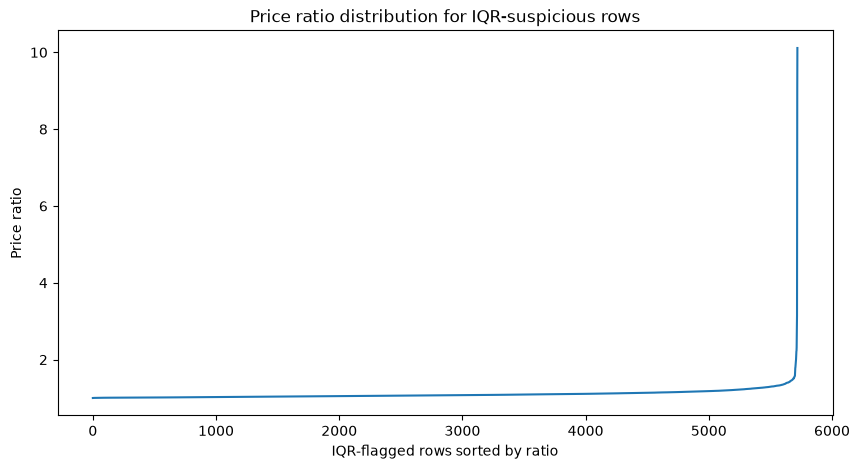

In [89]:


ratios = iqr_suspicious["price_ratio"].sort_values().reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(ratios)
plt.xlabel("IQR-flagged rows sorted by ratio")
plt.ylabel("Price ratio")
plt.title("Price ratio distribution for IQR-suspicious rows")
plt.show()

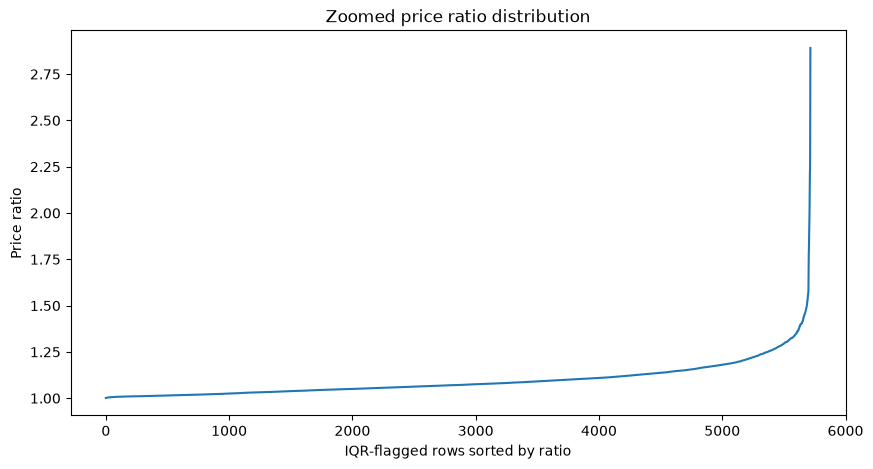

In [90]:
zoom = iqr_suspicious[
    iqr_suspicious["price_ratio"] <= 3
]["price_ratio"].sort_values().reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(zoom)
plt.xlabel("IQR-flagged rows sorted by ratio")
plt.ylabel("Price ratio")
plt.title("Zoomed price ratio distribution")
plt.show()

In [91]:
iqr_suspicious["price_ratio"].quantile(
    [0.90, 0.95, 0.975, 0.99, 0.995, 0.999]
)

0.900    1.199386
0.950    1.268830
0.975    1.329947
0.990    1.440009
0.995    1.524242
0.999    2.378628
Name: price_ratio, dtype: float64

In [239]:
boundary = iqr_suspicious[
    iqr_suspicious["price_ratio"].between(1.5, 2.2)
].sort_values("price_ratio")

boundary[
    ["hash", "train_price", "median_price", "price_ratio", "upper_bound"]
].head(30)

,hash,train_price,median_price,price_ratio,upper_bound
805969,97538938487450067,52013.0,34616.5,1.502549,47156.750
1757398,9117162619636016315,29379.0,19544.0,1.503223,20937.125
2272707,12149203812519832282,65890.0,43810.0,1.503995,51787.500
1588353,14969950921417855673,56531.0,37102.0,1.523664,46966.500
2509464,15019743789185687713,38720.0,25410.0,1.523810,30703.875
2016352,13334622098546296759,36350.0,23838.0,1.524876,26421.750
748729,14672401067160493625,91935.0,60140.0,1.528683,80052.500
1362223,6020719356542274416,38490.0,24990.0,1.540216,35865.000
1373076,17559615606376657986,103225.0,66695.0,1.547717,102720.000
325340,15694201612550986439,62016.0,39868.5,1.555514,55235.625


In [240]:
suspicious_hash = 			16463018253638026196	  # put any hash here


In [241]:
suspicious_hash

16463018253638026196

In [242]:
boundary[boundary["hash"] == suspicious_hash]

,hash,train_price,median_price,price_ratio,Q1,Q3,IQR,lower_bound,upper_bound
2039221,16463018253638026196,129495.0,65845.0,1.966664,63088.75,82695.0,19606.25,33679.375,112104.375


In [243]:
rows = X_train.loc[train_hashes == suspicious_hash].copy()
rows["price"] = y_train.loc[rows.index]

rows[
    [
        "make_name",
        "model_name",
        "year",
        "trim_name",
        "mileage",
        "is_new",
        "price"
    ]
].sort_values("price", ascending=False)

,make_name,model_name,year,trim_name,mileage,is_new,price
2039221,Ford,F-550 Super Duty Chassis,2020,Unknown,5.0,True,129495.0
2038725,Ford,F-550 Super Duty Chassis,2020,Unknown,5.0,True,67095.0
2038539,Ford,F-550 Super Duty Chassis,2020,Unknown,5.0,True,64595.0
2038003,Ford,F-550 Super Duty Chassis,2020,Unknown,5.0,True,58570.0


In [228]:
final_suspects = iqr_suspicious[
    iqr_suspicious["price_ratio"] >= 2.0
].copy()

final_suspects.shape

(12, 9)

In [229]:
final_suspects[
    ["hash", "train_price", "median_price", "price_ratio", "upper_bound"]
].sort_values("price_ratio", ascending=False)

,hash,train_price,median_price,price_ratio,upper_bound
185103,5492722262828514893,320150.0,31657.5,10.112927,213035.000
908517,6713839979747926329,421780.0,46421.0,9.085974,74813.500
908511,6713839979747926329,388860.0,46421.0,8.376812,74813.500
1013302,4385675512980245731,44895.0,14245.0,3.151632,35745.000
622652,2201697772946513314,115625.0,39995.5,2.890950,88019.000
2432566,191194700731645102,110625.0,43760.0,2.527994,57956.250
1959688,2089821197251354055,124992.0,53870.0,2.320252,57615.500
1729199,6889850549483076157,133995.0,59995.0,2.233436,96507.500
2551158,8735702626827990070,122523.0,55273.0,2.216688,68584.500
1161322,11332543365454279981,99795.0,45949.0,2.171864,68165.500


In [230]:
suspect_hashes = final_suspects["hash"].unique()

for h in suspect_hashes:
    rows = X_train.loc[train_hashes == h].copy()
    rows["price"] = y_train.loc[rows.index]

    print("\nHASH:", h)

    display(
        rows[
            [
                "make_name",
                "model_name",
                "year",
                "trim_name",
                "mileage",
                "is_new",
                "price"
            ]
        ].sort_values("price", ascending=False)
    )


HASH: 5492722262828514893


,make_name,model_name,year,trim_name,mileage,is_new,price
185103,Jeep,Compass,2021,Unknown,6.0,True,320150.0
184545,Jeep,Compass,2021,Unknown,6.0,True,31780.0
184542,Jeep,Compass,2021,Unknown,6.0,True,31535.0
184264,Jeep,Compass,2021,Unknown,6.0,True,29785.0



HASH: 6713839979747926329


,make_name,model_name,year,trim_name,mileage,is_new,price
908517,GMC,Acadia,2021,Unknown,5.0,True,421780.0
908511,GMC,Acadia,2021,Unknown,5.0,True,388860.0
907354,GMC,Acadia,2021,Unknown,5.0,True,51991.0
907289,GMC,Acadia,2021,Unknown,5.0,True,51787.0
907284,GMC,Acadia,2021,Unknown,5.0,True,51433.0
907875,GMC,Acadia,2021,Unknown,5.0,True,50154.0
907663,GMC,Acadia,2021,Unknown,5.0,True,48727.0
907648,GMC,Acadia,2021,Unknown,5.0,True,48169.0
907369,GMC,Acadia,2021,Unknown,5.0,True,46421.0
907320,GMC,Acadia,2021,Unknown,5.0,True,42407.0



HASH: 4385675512980245731


...

,make_name,model_name,year,trim_name,mileage,is_new,price
1161322,Ford,F-150,2020,Unknown,9.0,True,99795.0
1161170,Ford,F-150,2020,Unknown,9.0,True,60844.0
1160634,Ford,F-150,2020,Unknown,9.0,True,53508.0
1160624,Ford,F-150,2020,Unknown,9.0,True,53348.0
1160922,Ford,F-150,2020,Unknown,9.0,True,52810.0
1160849,Ford,F-150,2020,Unknown,9.0,True,52415.0
1160770,Ford,F-150,2020,Unknown,9.0,True,52221.0
1160328,Ford,F-150,2020,Unknown,9.0,True,48706.0
1160320,Ford,F-150,2020,Unknown,9.0,True,47584.0
1160281,Ford,F-150,2020,Unknown,9.0,True,46846.0



HASH: 8204408092826420761


,make_name,model_name,year,trim_name,mileage,is_new,price
639585,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,124950.0
639534,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,63230.0
639665,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,61320.0
639648,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,59420.0
639623,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,58725.0
639532,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,49035.0
639856,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,46240.0



HASH: 18233584322250405731


,make_name,model_name,year,trim_name,mileage,is_new,price
2453528,Chevrolet,Bolt EV,2020,LT FWD,4.0,True,40479.0
1894930,Chevrolet,Bolt EV,2020,LT FWD,4.0,True,20790.0
1894825,Chevrolet,Bolt EV,2020,LT FWD,4.0,True,19645.0
1894787,Chevrolet,Bolt EV,2020,LT FWD,4.0,True,19495.0


In [236]:
ratio_only_suspects = train_analysis[
    train_analysis["price_ratio"] >= 2.0
].sort_values("price_ratio", ascending=False)

ratio_only_suspects.shape

(13, 9)

In [237]:
missed_by_iqr = ratio_only_suspects[
    ~ratio_only_suspects.index.isin(final_suspects.index)
]

missed_by_iqr[
    ["hash", "train_price", "median_price", "price_ratio"]
].sort_values("price_ratio", ascending=False)

,hash,train_price,median_price,price_ratio
1303333,11453892623244399690,129971.0,58366.0,2.226827


In [244]:
train_analysis[
    train_analysis["hash"] == 16468349563739211745
]

,hash,train_price,median_price,price_ratio,Q1,Q3,IQR,lower_bound,upper_bound
2537100,16468349563739211745,1116711.0,587780.5,1.899878,323315.25,852245.75,528930.5,-470080.5,1645641.5
2535958,16468349563739211745,58850.0,587780.5,0.100122,323315.25,852245.75,528930.5,-470080.5,1645641.5


In [246]:
hash_sizes = train_analysis["hash"].value_counts()

In [248]:
two_row_hashes = hash_sizes[hash_sizes == 2].index

In [249]:
two_row_groups = train_analysis[
    train_analysis["hash"].isin(two_row_hashes)
].copy()

In [250]:
len(two_row_hashes)

82198

In [251]:
two_row_groups.shape

(164396, 9)

In [252]:
two_row_stats = (
    two_row_groups
    .groupby("hash")["train_price"]
    .agg(low_price="min", high_price="max")
)

two_row_stats["pair_ratio"] = (
    two_row_stats["high_price"] /
    two_row_stats["low_price"]
)

In [253]:
two_row_stats.sort_values(
    "pair_ratio",
    ascending=False
).head(50)

,low_price,high_price,pair_ratio
hash,,,
16468349563739211745,58850.0,1116711.0,18.975548
14803983939421439104,33530.0,404843.0,12.074053
5819295803134546611,48395.0,492300.0,10.172538
4584339353417299132,61470.0,496302.0,8.073890
14084691165661291626,5495.0,21995.0,4.002730
4552947140140772645,25725.0,99999.0,3.887230
8617653938838525900,9995.0,32995.0,3.301151
17289268863822870986,10695.0,34950.0,3.267882
75363959543758810,46850.0,138250.0,2.950907


In [260]:
suspicious_hash = 17289268863822870986		   # replace with any 2-row hash

rows = X_train.loc[train_hashes == suspicious_hash].copy()
rows["price"] = y_train.loc[rows.index]

display(
    rows[
        [
            "make_name",
            "model_name",
            "year",
            "trim_name",
            "mileage",
            "is_new",
            "price"
        ]
    ].sort_values("price", ascending=False)
)

display(two_row_stats.loc[[suspicious_hash]])

,make_name,model_name,year,trim_name,mileage,is_new,price
1942058,Chrysler,Town & Country,2014,Touring FWD,41308.0,False,34950.0
1941346,Chrysler,Town & Country,2014,Touring FWD,41308.0,False,10695.0


,low_price,high_price,pair_ratio
hash,,,
17289268863822870986,10695.0,34950.0,3.267882


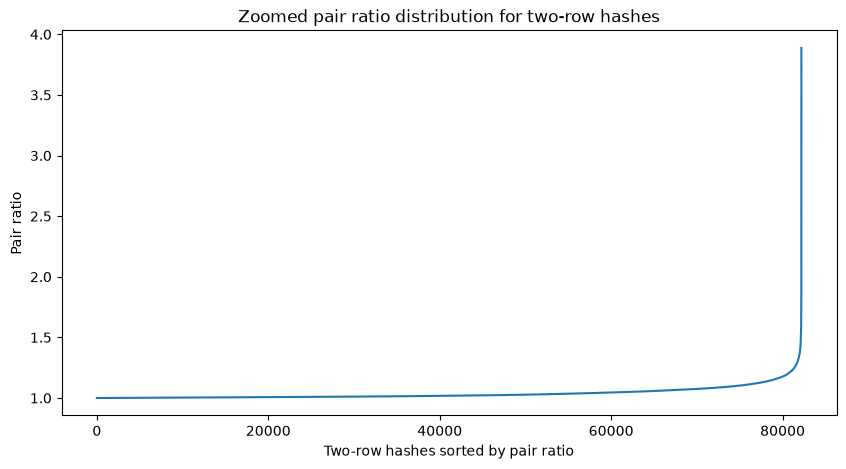

In [256]:


pair_ratios = (
    two_row_stats["pair_ratio"]
    .sort_values()
    .reset_index(drop=True)
)

zoom_pair = pair_ratios[pair_ratios <= 4]

plt.figure(figsize=(10, 5))

plt.plot(zoom_pair)

plt.xlabel("Two-row hashes sorted by pair ratio")
plt.ylabel("Pair ratio")
plt.title("Zoomed pair ratio distribution for two-row hashes")

plt.show()

In [261]:
bad_two_row_hashes = two_row_stats.loc[two_row_stats["pair_ratio"] >= 3]
bad_two_row_groups = two_row_groups[
    two_row_groups["hash"].isin(bad_two_row_hashes.index)
]
two_rows_suspicious = bad_two_row_groups.groupby('hash')['train_price'].idxmax()

In [262]:
three_plus_hashes = hash_sizes[hash_sizes >= 3].index
three_plus_groups = train_analysis[
    train_analysis["hash"].isin(three_plus_hashes)
]
three_plus_suspicious = three_plus_groups[
    (three_plus_groups["train_price"] > three_plus_groups["upper_bound"]) &
    (three_plus_groups["price_ratio"] >= 2.0)
]

In [264]:
three_plus_suspicious.shape

(12, 9)

In [265]:
two_rows_suspicious.shape

(8,)

In [266]:
bad_row_indices = pd.Index(two_rows_suspicious.values).union(three_plus_suspicious.index)

In [267]:
len(bad_row_indices)

20

In [268]:
check_bad_rows = X_train.loc[bad_row_indices].copy()
check_bad_rows["price"] = y_train.loc[bad_row_indices]

check_bad_rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
185103,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,320150.0
453533,Attica,Unknown,Not Reported,Unknown,Not Reported,345.0,True,Chevrolet,3.0,Blazer,...,A,Unknown,Unknown,2021,0,1,False,False,False,492300.0
622652,Sterling,V8 Flex Fuel Vehicle,Not Reported,Flex Fuel Vehicle,Not Reported,381.0,True,Ford,0.0,F-150,...,A,Unknown,Unknown,2020,0,1,False,False,False,115625.0
639585,Pittsburgh,Unknown,Not Reported,Unknown,Not Reported,345.0,True,Ford,10.0,F-550 Super Duty Chassis,...,A,Unknown,Unknown,2020,0,1,False,False,False,124950.0
908511,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,388860.0
908517,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,421780.0
1008668,Cadillac,Unknown,False,Unknown,False,345.0,False,Ford,41308.0,Thunderbird,...,Unknown,Unknown,Unknown,1964,1,1,False,True,True,21995.0
1009519,Cadillac,Unknown,False,Unknown,False,345.0,False,Ford,41308.0,Thunderbird,...,Unknown,Unknown,Unknown,1960,1,1,False,True,True,32995.0
1013302,Cadillac,Unknown,False,Unknown,False,345.0,False,Ford,41308.0,Model A,...,Unknown,Pickup,Unknown,1930,1,1,False,True,True,44895.0
1075207,Blackshear,I4,Not Reported,Gasoline,Not Reported,180.0,True,Ford,15.0,Ranger,...,A,Unknown,Unknown,2020,0,1,False,False,False,404843.0


In [275]:
X_train = X_train.drop(bad_row_indices)
y_train = y_train.drop(bad_row_indices)

In [276]:
X_train.shape


(2130184, 21)

In [277]:
y_train.shape

(2130184,)